# Gamma Probability Distribution

## 1. Definition

## 2. Intuition


## 3. Parameter

## 4. Support

## 5. Probability Mass Function


## 6. Cumulative Distribution Function


## 7. Moments

## 8. NumPy Implementation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.special import erf, gammainc, gammaln, betainc, betaln


def validate_sample_size(size):
    if not isinstance(size, (int, np.integer)):
        raise TypeError("size must be an integer.")

    if size < 1:
        raise ValueError("size must be at least 1.")

In [2]:
class Gamma:
    """
    Gamma distribution parameterized by shape alpha
    and scale theta.
    """

    def __init__(self, alpha: float, theta: float = 1.0):
        if not np.isfinite(alpha) or alpha <= 0:
            raise ValueError(
                "alpha must be finite and greater than 0."
            )

        if not np.isfinite(theta) or theta <= 0:
            raise ValueError(
                "theta must be finite and greater than 0."
            )

        self.alpha = float(alpha)
        self.theta = float(theta)

    def pdf(self, x):
        x = np.asarray(x)

        density = np.zeros_like(x, dtype=float)

        positive = x > 0

        x_valid = x[positive]

        # Log-space calculation for numerical stability
        log_density = (
            (self.alpha - 1) * np.log(x_valid)
            - x_valid / self.theta
            - gammaln(self.alpha)
            - self.alpha * np.log(self.theta)
        )

        density[positive] = np.exp(log_density)

        # Boundary x = 0
        at_zero = x == 0

        if self.alpha == 1:
            density[at_zero] = 1.0 / self.theta
        elif self.alpha < 1:
            density[at_zero] = np.inf

        return density

    def cdf(self, x):
        x = np.asarray(x)

        probability = np.zeros_like(x, dtype=float)

        valid = x >= 0

        probability[valid] = gammainc(
            self.alpha,
            x[valid] / self.theta,
        )

        return probability

    def mean(self):
        return self.alpha * self.theta

    def variance(self):
        return self.alpha * self.theta**2

    def sample(self, size=1, random_state=None):
        validate_sample_size(size)

        rng = np.random.default_rng(random_state)

        return rng.gamma(
            shape=self.alpha,
            scale=self.theta,
            size=size,
        )

    def plot(self, num_points=500, figsize=(10, 4)):
        standard_deviation = np.sqrt(self.variance())

        upper_limit = (
            self.mean()
            + 5 * standard_deviation
        )

        x = np.linspace(
            1e-8,
            upper_limit,
            num_points,
        )

        fig, axes = plt.subplots(1, 2, figsize=figsize)

        axes[0].plot(x, self.pdf(x))
        axes[0].axvline(
            self.mean(),
            linestyle="--",
            label=f"Mean = {self.mean():.2f}",
        )
        axes[0].set_title("Gamma PDF")
        axes[0].set_xlabel("x")
        axes[0].set_ylabel("Density")
        axes[0].legend()
        axes[0].grid(True)

        axes[1].plot(x, self.cdf(x))
        axes[1].set_title("Gamma CDF")
        axes[1].set_xlabel("x")
        axes[1].set_ylabel("Cumulative probability")
        axes[1].set_ylim(-0.05, 1.05)
        axes[1].grid(True)

        plt.tight_layout()
        plt.show()

Gamma mean: 6.0
Gamma variance: 12.0


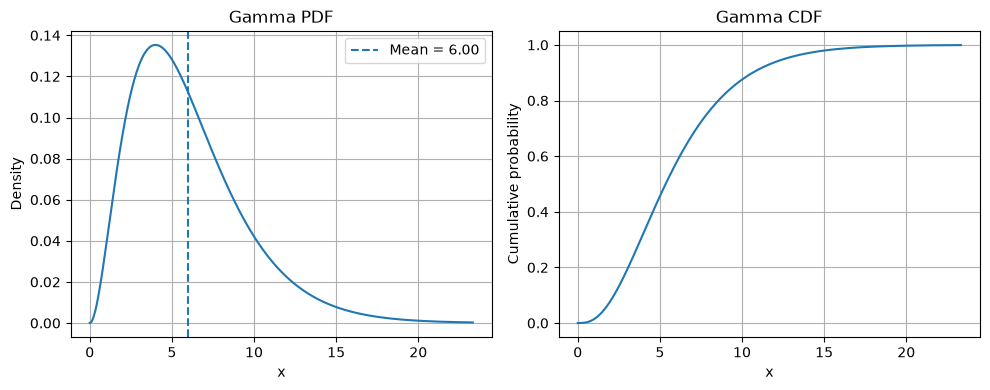

In [3]:
gamma = Gamma(alpha=3, theta=2)
print("Gamma mean:", gamma.mean())
print("Gamma variance:", gamma.variance())
gamma.plot()